# fine-tuning base-case-bert and roberta models with HC3 datasets.
# it also checked the confusion_matrix

In [1]:
# downloading necessary libraries
!pip install transformers
!pip install torch
!pip install huggingface_hub
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.0 MB/s eta 0:00:00


# data download

In [2]:
import torch
import transformers

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from datasets import load_dataset

# load a custom CSV file
data_files = {"train": "/content/drive/MyDrive/Colab Notebooks/NLU_project/GPT5.4-mini-data/new_train.csv", "val": "/content/drive/MyDrive/Colab Notebooks/NLU_project/GPT5.4-mini-data/new_val.csv", "test": "/content/drive/MyDrive/Colab Notebooks/NLU_project/GPT5.4-mini-data/new_test.csv"}
dataset = load_dataset("csv", data_files=data_files)

Generating train split: 0 examples [00:00, ? examples/s]

Generating val split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 85894
    })
    val: Dataset({
        features: ['text', 'label'],
        num_rows: 11119
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 11110
    })
})

# base-case-bert training

In [ ]:
# from https://medium.com/@heyamit10/fine-tuning-bert-for-classification-a-practical-guide-b8c1c56f252c
device = torch.device("cuda")
# tokenization with BERT
from transformers import AutoTokenizer
# initialize the bert tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
def tokenize_function(examples):
    # ensure all elements in the 'text' batch are strings because of the type error
    texts = [str(t) if t is not None else "" for t in examples["text"]]
    return tokenizer(texts, padding="max_length", truncation=True, max_length=512)

# apply the tokenizer to the dataset
tokenized_datasets = dataset.map(tokenize_function, batched=True)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/85894 [00:00<?, ? examples/s]

Map:   0%|          | 0/11119 [00:00<?, ? examples/s]

Map:   0%|          | 0/11110 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

# initialize a BERT model for binary classification
model_name = "bert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).cuda()
model.to(device)
print(model.config)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



In [ ]:
# freeze all layers except the classifier
for param in model.bert.parameters():
    param.requires_grad = False

# keep only the classification head trainable
for param in model.classifier.parameters():
    param.requires_grad = True

In [ ]:
from transformers import TrainingArguments

# define training arguments
training_args = TrainingArguments(
    output_dir="./results",           # directory for saving model checkpoints
    eval_strategy ="epoch",     # evaluate at the end of each epoch
    learning_rate=5e-5,              # the same rate as the original paper
    per_device_train_batch_size=32,  # batch size per GPU and the same rate as the original paper
    per_device_eval_batch_size=32,
    num_train_epochs=30,              # number of epochs
    weight_decay=0.01,               # regularization
    save_total_limit=2,              # limit checkpoints to save space
    save_strategy = "epoch",
    load_best_model_at_end=True,     # automatically load the best checkpoint
    logging_dir="./logs",            # directory for logs
    logging_steps=100,               # log every 100 steps
    fp16=True                        # enable mixed precision for faster training
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer
from evaluate import load

# load a metric (F1-score in this case)
metric = load("f1")

# define a custom compute_metrics function for computing f1 score
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [ ]:
# installing data_collator for efficient batching
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
# enter all of the settings into trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["val"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)
from transformers import EarlyStoppingCallback
# install early stopping to finish learning at the optimal epoch.
trainer.add_callback(EarlyStoppingCallback(early_stopping_patience=2))
torch.cuda.empty_cache()

# Start training
trainer.train()


Epoch,Training Loss,Validation Loss,F1
1,0.511705,0.500851,0.800407
2,0.461247,0.458716,0.812246
3,0.428416,0.432165,0.823068
4,0.408966,0.411403,0.830032
5,0.393017,0.391063,0.838641
6,0.382335,0.389970,0.838554
7,0.385502,0.381007,0.842069
8,0.381128,0.368141,0.848410
9,0.379659,0.368999,0.846881
10,0.368122,0.358225,0.853123


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=48330, training_loss=0.39599964533339566, metrics={'train_runtime': 3910.6753, 'train_samples_per_second': 658.919, 'train_steps_per_second': 20.597, 'total_flos': 4.067938978036531e+17, 'train_loss': 0.39599964533339566, 'epoch': 18.0})

In [ ]:
# evaluate the model
results = trainer.evaluate()
print(results)

{'eval_loss': 0.33941295742988586, 'eval_f1': 0.862248960452977, 'eval_runtime': 22.2822, 'eval_samples_per_second': 499.008, 'eval_steps_per_second': 15.618, 'epoch': 18.0}


              precision    recall  f1-score   support

           0       0.92      0.81      0.86      5803
           1       0.82      0.93      0.87      5307

    accuracy                           0.87     11110
   macro avg       0.87      0.87      0.87     11110
weighted avg       0.87      0.87      0.87     11110



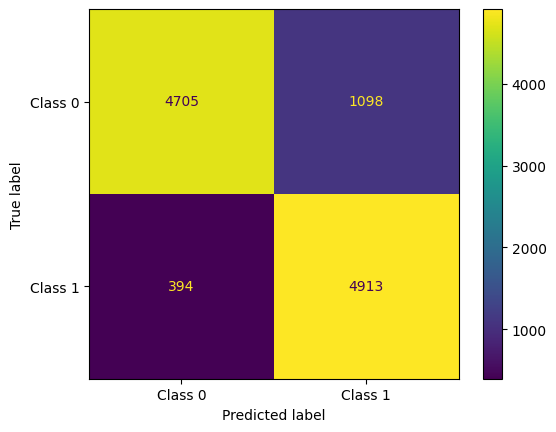

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# generate predictions
predictions = trainer.predict(tokenized_datasets["test"])
predicted_labels = predictions.predictions.argmax(axis=-1)

# classification report and print out
print(classification_report(tokenized_datasets["test"]["label"], predicted_labels))

# creating confusion matrix and plot at a figure
cm = confusion_matrix(tokenized_datasets["test"]["label"], predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot()

# remove the GPU cache
torch.cuda.empty_cache()

# Roberta training

In [ ]:
#robert necessary libraries
from transformers import RobertaForSequenceClassification
from transformers import RobertaTokenizer
from transformers import TrainingArguments
from transformers import DataCollatorWithPadding
from transformers import EarlyStoppingCallback
from transformers import Trainer
from evaluate import load


device = torch.device("cuda")
# tokenization with BERT
# initialize the bert tokenizer
model_name = "FacebookAI/roberta-base"
tokenizer = RobertaTokenizer.from_pretrained(model_name)

# the code below is the same as codes in BERT training


def tokenize_function(examples):
    texts = [str(t) if t is not None else "" for t in examples["text"]]
    return tokenizer(texts, padding="max_length", truncation=True, max_length=512)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2).cuda()
model.to(device)

for param in model.roberta.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy ="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=30,
    weight_decay=0.01,
    save_total_limit=2,
    save_strategy = "epoch",
    load_best_model_at_end=True,
    logging_dir="./logs",
    logging_steps=100,
    fp16=True
)

metric = load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return metric.compute(predictions=predictions, references=labels)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["val"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.add_callback(EarlyStoppingCallback(early_stopping_patience=2))

# remove the GPU cache
torch.cuda.empty_cache()

# Start training
trainer.train()

# Evaluate the model
results = trainer.evaluate()
print(results)



tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/85894 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

{'eval_loss': 0.02549104578793049, 'eval_f1': 0.9895287958115183, 'eval_runtime': 18.795, 'eval_samples_per_second': 591.594, 'eval_steps_per_second': 18.516, 'epoch': 12.0}


              precision    recall  f1-score   support

           0       1.00      0.98      0.99      5803
           1       0.98      1.00      0.99      5307

    accuracy                           0.99     11110
   macro avg       0.99      0.99      0.99     11110
weighted avg       0.99      0.99      0.99     11110



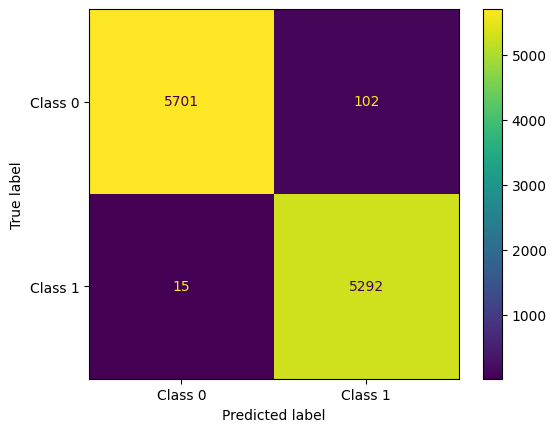

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Generate predictions
predictions = trainer.predict(tokenized_datasets["test"])
predicted_labels = predictions.predictions.argmax(axis=-1)

# Classification report
print(classification_report(tokenized_datasets["test"]["label"], predicted_labels))

# Confusion matrix
cm = confusion_matrix(tokenized_datasets["test"]["label"], predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot()

In [ ]:
save_directory = "/content/drive/MyDrive/Colab Notebooks/NLU_project/models_3"
# save the model and tokenizer
trainer.save_model(save_directory)
tokenizer.save_pretrained(save_directory)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/Colab Notebooks/NLU_project/models_3/tokenizer_config.json',
 '/content/drive/MyDrive/Colab Notebooks/NLU_project/models_3/tokenizer.json')

# using shap function


In [4]:
from datasets import load_dataset


# load a custom CSV file
data_files = {"train": "/content/drive/MyDrive/Colab Notebooks/NLU_project/GPT5.4-mini-data/new_train.csv", "val": "/content/drive/MyDrive/Colab Notebooks/NLU_project/GPT5.4-mini-data/new_val.csv", "test": "/content/drive/MyDrive/Colab Notebooks/NLU_project/GPT5.4-mini-data/new_test.csv"}
dataset = load_dataset("csv", data_files=data_files)

Generating train split: 0 examples [00:00, ? examples/s]

Generating val split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [11]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_dir = "/content/drive/MyDrive/Colab Notebooks/NLU_project/models_GPT5.4-mini"
loaded_model = AutoModelForSequenceClassification.from_pretrained(model_dir).cuda()
loaded_tokenizer = AutoTokenizer.from_pretrained(model_dir)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [12]:
def tokenize_function(examples):
    texts = [str(t) if t is not None else "" for t in examples["text"]]
    return loaded_tokenizer(texts, padding="max_length", truncation=True, max_length=512)

# Apply the tokenizer to the dataset
tokenized_datasets = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/11110 [00:00<?, ? examples/s]

In [ ]:
import numpy as np
import scipy as sp
import shap
import torch
# from shap library
# define a prediction function
def f(x):
    tv = torch.tensor([loaded_tokenizer.encode(v, padding="max_length", max_length=500, truncation=True) for v in x]).cuda()
    outputs = loaded_model(tv)[0].detach().cpu().numpy()
    scores = (np.exp(outputs).T / np.exp(outputs).sum(-1)).T
    val = sp.special.logit(scores[:, 1])  # use one vs rest logit units
    return val

# Create SHAP explainer
explainer = shap.Explainer(f, loaded_tokenizer)
#shap_data = pd.DataFrame({"text": tokenized_datasets['test']["text"], 'real': tokenized_datasets['test']["label"]})
shap_values = explainer(tokenized_datasets['test']['text'][:100], fixed_context=1)

PartitionExplainer explainer:   3%|▎         | 3/100 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   5%|▌         | 5/100 [00:30<15:40,  9.90s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   6%|▌         | 6/100 [00:46<20:03, 12.81s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   7%|▋         | 7/100 [00:52<15:27,  9.97s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

In [ ]:
shap.plots.bar(shap_values.mean(0))

In [ ]:
shap.plots.bar(shap_values.max(0))

In [ ]:
# Visualize explanations for one example
shap.plots.text(shap_values[0])

#references
-Bert documentation
https://huggingface.co/docs/transformers/model_doc/bert
- shap documentation
https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html#Explaining-a-transformers-NLP-model

-https://medium.com/@heyamit10/fine-tuning-bert-for-classification-a-practical-guide-b8c1c56f252c